# IND320 - Project work, part 1: Dashboard basics

**Author:** Mohammad Elmeziani (GitHub: `mokakao`)
**Course:** IND320 Data to decision, autumn 2026

| | |
| --- | --- |
| **GitHub repository** | https://github.com/mokakao/ind320-mokakao |
| **Streamlit app** | https://ind320-mokakao.streamlit.app |
| **Screencast** | *(link added as a submission comment in Canvas)* |

This notebook is the development and documentation platform for the project.
It reads the NVE reservoir data, renames the columns to English, shows the
contents, and plots the series. The same data loading is reused by the
Streamlit app in this repository.

## Declaration of AI usage

This work was produced with heavy use of AI. **Claude (Anthropic) wrote the code
in this notebook and in the Streamlit app, and drafted this log**, working from
the assignment text, the course material and the lecture recordings. My own
contributions were to decide how the work should be done, to create the GitHub
repository and deploy the app, to review the code and ask for explanations of
every part of it until I could account for it, and to record the screencast.

Concretely, AI was used to:

* choose how to reshape the long-format CSV into comparable time series,
* write `utils.py`, the four Streamlit pages and this notebook,
* explain `st.cache_data`, `st.column_config.LineChartColumn`, `st.selectbox`
  and `st.select_slider`, and why the app reruns from top to bottom,
* test the app page by page with `streamlit.testing.v1.AppTest` before deploying.

No other AI services were used. The course allows this (category K3 at NMBU),
provided the use is stated openly, which is the purpose of this section.

## Log

*(457 words.)*

**Getting started.** The practical setup took longer than the code. Python 3.12
was installed with `uv` because the course pins that version, and the project was
placed in its own folder so that it maps onto a single clean GitHub repository,
as recommended in the lecture. Creating the repository and connecting it to
Streamlit Cloud was straightforward, but pushing from the terminal did not work
at first: GitHub Desktop stores its login where the command line does not look
for it, so commits are made locally and pushed from GitHub Desktop instead.

**The data.** The file `reservoirs.csv` holds NVE's weekly reservoir statistics
from January 1995 onwards, 14 877 rows in total. Two properties of the file
shaped the whole notebook. First, it is in *long* format: one row per area per
week, with nine areas (five electricity price areas, three watercourse areas and
the country as a whole). Plotting "each column" of the raw file would therefore
mix nine different areas into one line. The data is filtered to Norway as a
whole, which leaves one row per week and turns every remaining column into a
single comparable series. Second, the rows are **not sorted by date**. A plot
made before sorting is an unreadable tangle, which is a mistake that is easy to
make and hard to spot, and the lecturer warned about exactly this.

**The Jupyter part.** The columns were renamed from Norwegian to English, as the
assignment requires. The contents are shown with `head()`, `info()` and
`describe()`, which together give the shape, the data types, the period covered
and the value ranges. Each series is then plotted separately, and afterwards all
of them together. The combined plot is the interesting one: `capacity_TWh` is
around 87, `fill_level` lies between 0 and 1, and `fill_level_change` is near
zero, so on a shared axis only the TWh series are visible. Scaling each series
to the same range makes the shapes comparable, at the cost of the units, and
that trade-off is shown explicitly with both versions of the plot.

**The Streamlit part.** The app has four pages in separate files, and Streamlit
builds the sidebar menu from the `pages/` folder automatically. The table page
transposes the data so that each series becomes a row with a small line chart of
the first month, using `LineChartColumn`. The plot page combines a `selectbox`
and a `select_slider`. Because Streamlit reruns the entire script on every
interaction, the data loading is wrapped in `@st.cache_data`; without it the file
would be read again on every click. Each page was tested with `AppTest` before
deployment, which also caught a deprecated argument that would have broken the
app on the newer Streamlit version used by the cloud service.

## 1. Setup

In [1]:
# pandas for reading and reshaping the data, matplotlib for the plots.
import matplotlib.pyplot as plt
import pandas as pd

# Show all columns when printing tables, and use a readable default figure size.
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 2. Read the data

The file is read straight from the repository so that the notebook and the
Streamlit app use exactly the same copy of the data.

In [2]:
# The notebook lives in notebooks/, the data one level up in data/.
raw = pd.read_csv("../data/reservoirs.csv")

print("Rows and columns:", raw.shape)
raw.head()

Rows and columns: (14877, 11)


,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


### Rename the headers to English

The original headers are Norwegian. The assignment asks for headers that are
"English and understandable", and the course wants the whole project in English
so that other students can read it.

In [3]:
# Norwegian -> English. The comments explain what the less obvious columns mean.
column_names = {
    "dato_Id": "date",
    "omrType": "area_type",                             # EL, VASS or NO
    "omrnr": "area_number",
    "iso_aar": "iso_year",
    "iso_uke": "iso_week",
    "fyllingsgrad": "fill_level",                       # share of capacity, 0-1
    "kapasitet_TWh": "capacity_TWh",                    # maximum storage, TWh
    "fylling_TWh": "stored_TWh",                        # energy stored, TWh
    "neste_Publiseringsdato": "next_publication_date",
    "fyllingsgrad_forrige_uke": "fill_level_previous_week",
    "endring_fyllingsgrad": "fill_level_change",        # change since last week
}

data = raw.rename(columns=column_names)
list(data.columns)

['date',
 'area_type',
 'area_number',
 'iso_year',
 'iso_week',
 'fill_level',
 'capacity_TWh',
 'stored_TWh',
 'next_publication_date',
 'fill_level_previous_week',
 'fill_level_change']

## 3. Print the contents in a relevant way

Three views answer three different questions: `head()` shows what a row looks
like, `info()` shows the data types and whether anything is missing, and
`describe()` shows the range of the numbers.

In [4]:
# What does a row look like?
data.head()

,date,area_type,area_number,iso_year,iso_week,fill_level,capacity_TWh,stored_TWh,next_publication_date,fill_level_previous_week,fill_level_change
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


In [5]:
# Data types and missing values.
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 14877 entries, 0 to 14876
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date                      14877 non-null  str    
 1   area_type                 14877 non-null  str    
 2   area_number               14877 non-null  int64  
 3   iso_year                  14877 non-null  int64  
 4   iso_week                  14877 non-null  int64  
 5   fill_level                14877 non-null  float64
 6   capacity_TWh              14877 non-null  float64
 7   stored_TWh                14877 non-null  float64
 8   next_publication_date     14877 non-null  str    
 9   fill_level_previous_week  14877 non-null  float64
 10  fill_level_change         14877 non-null  float64
dtypes: float64(5), int64(3), str(3)
memory usage: 1.2 MB


In [6]:
# Value ranges. .T transposes the summary so that one row is one column of data.
data.describe().T

,count,mean,std,min,25%,50%,75%,max
area_number,14877.0,2.333333,1.490762,0.000000,1.000000,2.000000,3.000000,5.000000
iso_year,14877.0,2010.346038,9.146696,1995.000000,2002.000000,2010.000000,2018.000000,2026.000000
iso_week,14877.0,26.405929,15.017910,1.000000,13.000000,26.000000,39.000000,53.000000
fill_level,14877.0,0.618852,0.214850,0.055160,0.456234,0.648049,0.802135,1.020072
capacity_TWh,14877.0,29.145860,22.739070,6.003264,17.390587,23.237715,34.043590,87.437580
stored_TWh,14877.0,18.139713,15.966211,0.331142,7.321973,14.501389,22.203530,84.544820
fill_level_previous_week,14877.0,0.618890,0.214843,0.055160,0.456356,0.648114,0.802133,1.020037
fill_level_change,14877.0,-0.000038,0.031385,-0.242484,-0.022395,-0.007072,0.016277,0.336623


### The file is in long format

The file is not one table of series: it holds nine areas stacked on top of each
other, one row per area per week. This has to be handled before plotting.

In [7]:
# How many rows per area, and what period does each one cover?
summary = (
    data.groupby(["area_type", "area_number"])
    .agg(rows=("date", "size"), first=("date", "min"), last=("date", "max"))
)
summary

rows       first        last
area_type area_number                              
EL        1            1653  1995-01-08  2026-09-06
          2            1653  1995-01-08  2026-09-06
          3            1653  1995-01-08  2026-09-06
          4            1653  1995-01-08  2026-09-06
          5            1653  1995-01-08  2026-09-06
NO        0            1653  1995-01-08  2026-09-06
VASS      1            1653  1995-01-08  2026-09-06
          2            1653  1995-01-08  2026-09-06
          3            1653  1995-01-08  2026-09-06

**Reading the table above:** five electricity price areas (`EL1`-`EL5`), three
watercourse areas (`VASS1`-`VASS3`) and the country as a whole (`NO`, area 0),
each with 1 653 weekly measurements from January 1995 onwards.

The rest of the notebook uses **Norway as a whole**, so that each remaining
column is a single series over time. The same choice is made in the app.

In [8]:
# Keep the national figures only.
norway = data[(data["area_type"] == "NO") & (data["area_number"] == 0)].copy()

# The rows in the raw file are NOT in chronological order. Sorting before
# plotting is essential: an unsorted line plot jumps back and forth in time.
print("Sorted by date in the raw file:", norway["date"].is_monotonic_increasing)

norway["date"] = pd.to_datetime(norway["date"])
norway = norway.sort_values("date").set_index("date")

# The five numeric series to work with.
value_columns = [
    "fill_level",
    "fill_level_previous_week",
    "fill_level_change",
    "capacity_TWh",
    "stored_TWh",
]
series = norway[value_columns]
print("Sorted after fixing:", series.index.is_monotonic_increasing)
series.head()

Sorted by date in the raw file: False
Sorted after fixing: True


,fill_level,fill_level_previous_week,fill_level_change,capacity_TWh,stored_TWh
date,,,,,
1995-01-08,0.608274,0.752703,-0.144430,87.43758,53.185986
1995-01-15,0.582372,0.608274,-0.025902,87.43758,50.921207
1995-01-22,0.562412,0.582390,-0.019977,87.43758,49.175980
1995-01-29,0.534508,0.562412,-0.027904,87.43758,46.736122
1995-02-05,0.506486,0.534489,-0.028003,87.43758,44.285900


## 4. Plot each column separately

Each series gets its own axis, so each one is drawn on the scale that suits it.

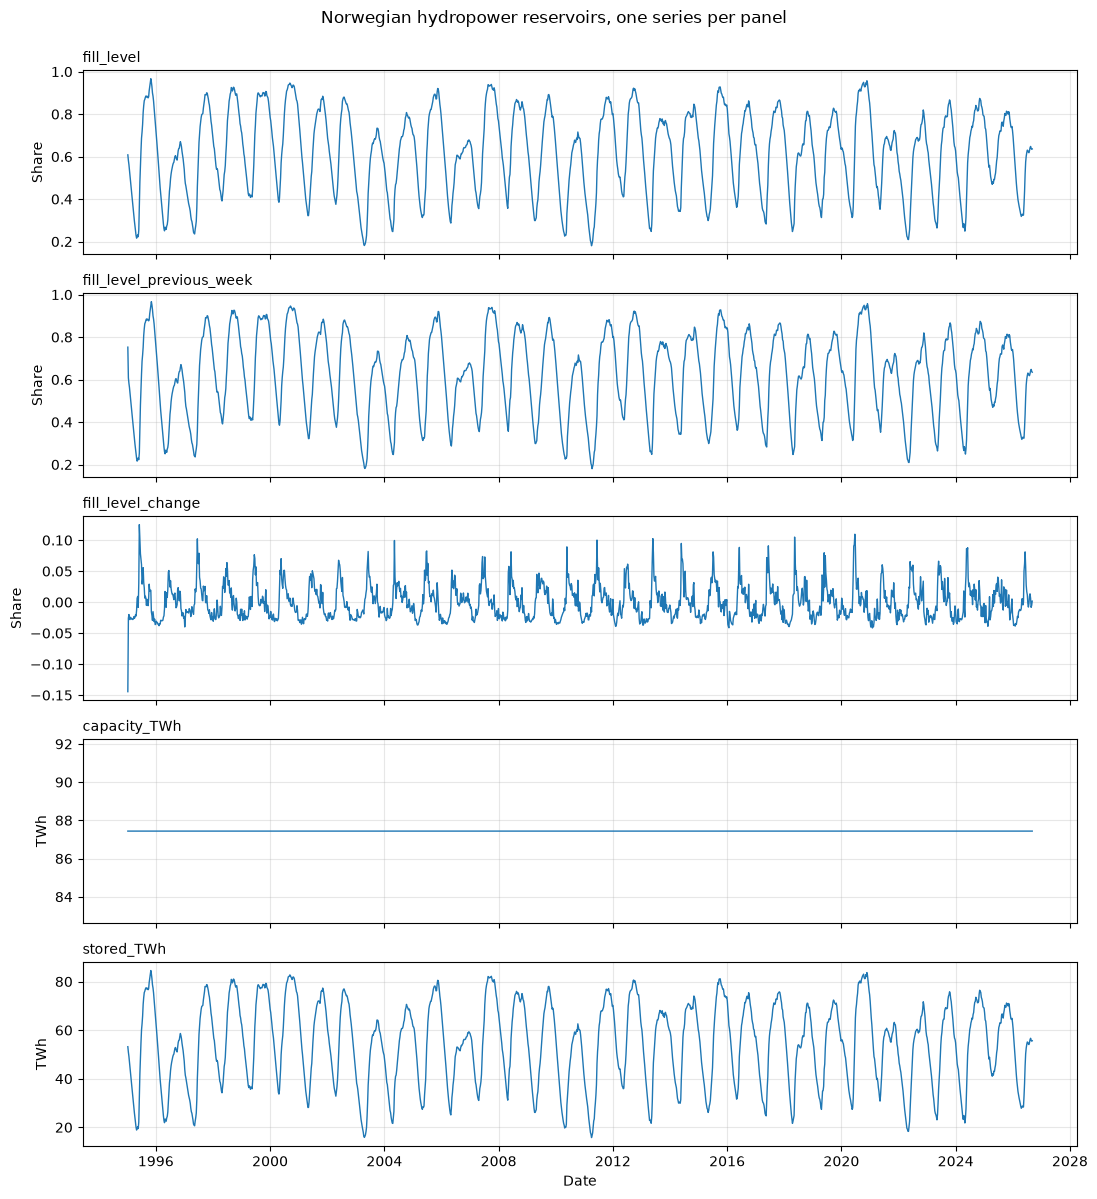

In [9]:
# One subplot per column, sharing the x-axis (time).
fig, axes = plt.subplots(len(value_columns), 1, figsize=(11, 12), sharex=True)

for ax, column in zip(axes, value_columns):
    ax.plot(series.index, series[column], linewidth=1.0)
    ax.set_title(column, fontsize=10, loc="left")
    # The unit differs between the series, so the y-label follows the column.
    ax.set_ylabel("TWh" if column.endswith("TWh") else "Share")

axes[-1].set_xlabel("Date")
fig.suptitle("Norwegian hydropower reservoirs, one series per panel", y=0.995)
fig.tight_layout()
plt.show()

**What the panels show.** `fill_level` and `stored_TWh` have a clear yearly
rhythm: the reservoirs fill through the autumn and empty through the winter.
`capacity_TWh` is almost a straight line, since the physical capacity only
changes when plants are built or rebuilt. `fill_level_change` oscillates around
zero and is the weekly difference, so it is noisy by nature.

## 5. Plot all columns together

The series are on very different scales, so this needs a decision rather than a
single plot. Both versions are shown: first the honest but unreadable one, then
a scaled version.

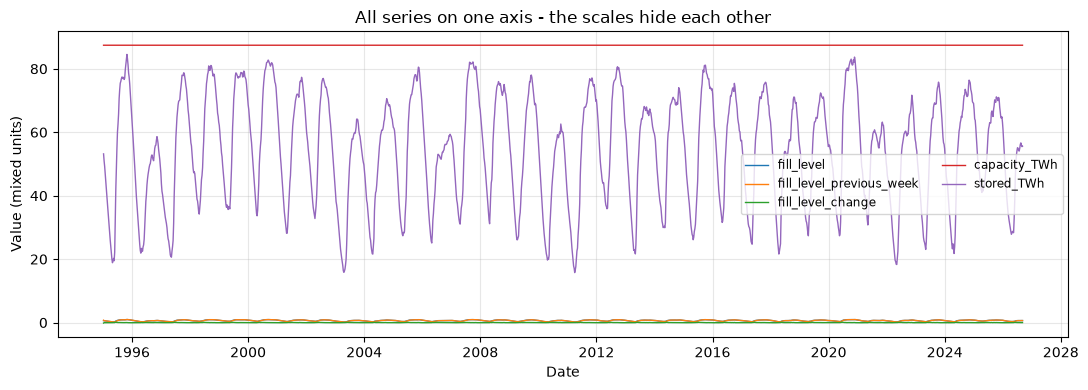

In [10]:
# Version 1: everything on one shared axis, exactly as it is stored.
fig, ax = plt.subplots()

for column in value_columns:
    ax.plot(series.index, series[column], linewidth=1.0, label=column)

ax.set_title("All series on one axis - the scales hide each other")
ax.set_xlabel("Date")
ax.set_ylabel("Value (mixed units)")
ax.legend(fontsize="small", ncol=2)
fig.tight_layout()
plt.show()

Only the two TWh series are visible. `fill_level` (0 to 1) and
`fill_level_change` (close to zero) are pressed flat against the bottom of the
plot, because they share an axis that runs up to about 87.

Two ways to fix it: give the small series their own axis, or scale every series
to a common range.

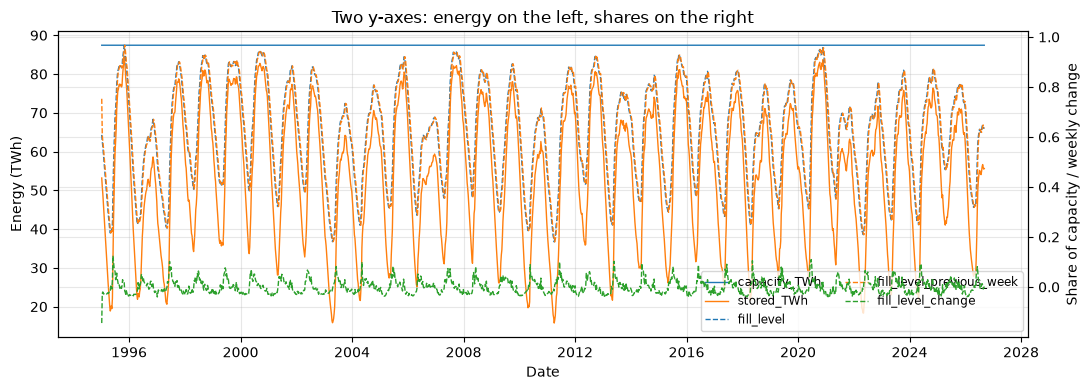

In [11]:
# Version 2a: two axes, one for the TWh series and one for the shares.
fig, ax_twh = plt.subplots()
ax_share = ax_twh.twinx()          # a second y-axis sharing the same x-axis

for column in ["capacity_TWh", "stored_TWh"]:
    ax_twh.plot(series.index, series[column], linewidth=1.0, label=column)

for column in ["fill_level", "fill_level_previous_week", "fill_level_change"]:
    ax_share.plot(
        series.index, series[column], linewidth=1.0, linestyle="--", label=column
    )

ax_twh.set_xlabel("Date")
ax_twh.set_ylabel("Energy (TWh)")
ax_share.set_ylabel("Share of capacity / weekly change")
ax_twh.set_title("Two y-axes: energy on the left, shares on the right")

# Combine the labels from both axes into a single legend.
lines = ax_twh.get_lines() + ax_share.get_lines()
ax_twh.legend(lines, [line.get_label() for line in lines], fontsize="small", ncol=2)
fig.tight_layout()
plt.show()

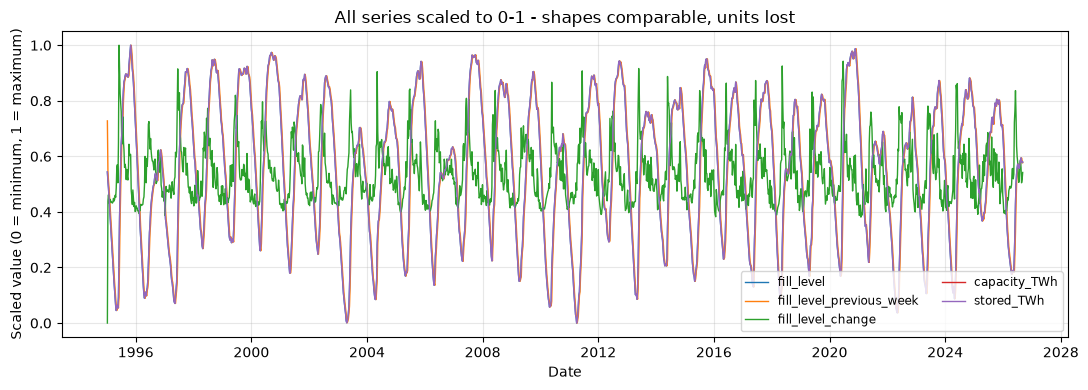

In [12]:
# Version 2b: scale every series to 0-1, so the shapes can be compared directly.
scaled = (series - series.min()) / (series.max() - series.min())

fig, ax = plt.subplots()
for column in value_columns:
    ax.plot(scaled.index, scaled[column], linewidth=1.0, label=column)

ax.set_title("All series scaled to 0-1 - shapes comparable, units lost")
ax.set_xlabel("Date")
ax.set_ylabel("Scaled value (0 = minimum, 1 = maximum)")
ax.legend(fontsize="small", ncol=2)
fig.tight_layout()
plt.show()

**Which one to use.** The two-axis version keeps the real units and works when
there are two groups of scales, as here. The scaled version works for any number
of series and makes the shapes easy to compare, but the axis no longer means
anything physical. The app uses the scaled version when "All columns" is
selected, and real units when a single column is chosen, so nothing is hidden
from the user.

A last look at the most recent years, where the reservoirs have been unusually
low:

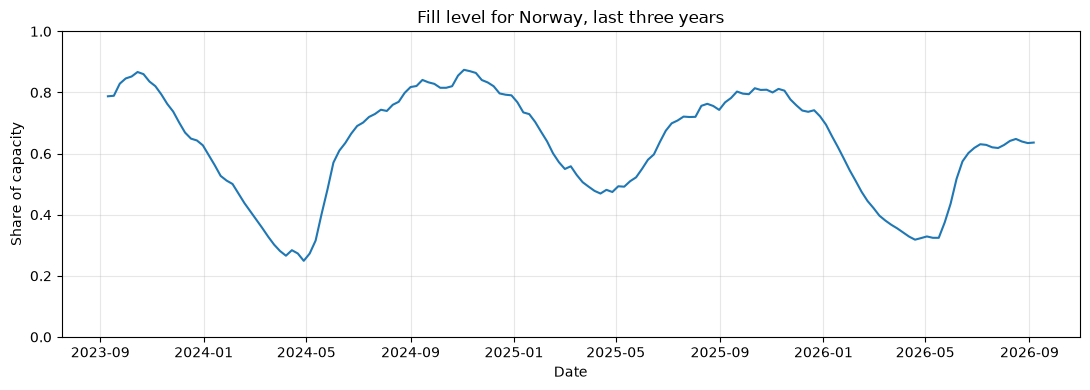

Latest measurement: 06 September 2026, fill level 63.6%


In [13]:
# Zoom in on the last three years of the fill level.
recent = series.loc[series.index >= series.index.max() - pd.DateOffset(years=3)]

fig, ax = plt.subplots()
ax.plot(recent.index, recent["fill_level"], linewidth=1.5)
ax.set_title("Fill level for Norway, last three years")
ax.set_xlabel("Date")
ax.set_ylabel("Share of capacity")
ax.set_ylim(0, 1)
fig.tight_layout()
plt.show()

print(f"Latest measurement: {recent.index.max():%d %B %Y}, "
      f"fill level {recent['fill_level'].iloc[-1]:.1%}")

## 6. What the app does with this

The Streamlit app reuses the steps above in `utils.py`: read the CSV, rename the
headers, keep Norway as a whole, sort by date and cache the result with
`@st.cache_data` so that the file is not read again on every interaction.

* **Data table** shows one row per series with a line chart of the first month.
* **Plots** has a dropdown for one column or all of them, and a month slider.
* **About** documents the data source and what comes next.

In part 2 the local CSV file is replaced by data from an API stored in MongoDB.